In [1]:
!pip -q install "monai[all]" nibabel pandas scikit-learn tqdm

import os, sys, time, glob, random
import numpy as np
import pandas as pd
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/1

In [2]:
import os, json, time
from pathlib import Path

PROJECT_DIR = Path("/content/work_oasis")
OUT_DIR = PROJECT_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    "project_name": "OASIS_CDR_proxy_baseline",
    "seed": 42,
    "img_size": (128, 128, 128),
    "batch_size": 2,
    "num_workers": 2,
    "max_epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "label_rule": "label = (CDR > 0)",
    "positive_class": 1,
    "out_dir": str(OUT_DIR),
    "best_model_path": str(OUT_DIR / "best_model.pt"),
}

print("OUT_DIR:", CFG["out_dir"])

OUT_DIR: /content/work_oasis/outputs


In [3]:
summary_txt = f"""
Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)

Model: MONAI DenseNet121 3D
Input size: {CFG["img_size"]}

Training:
epochs = {CFG["max_epochs"]}
batch_size = {CFG["batch_size"]}
lr = {CFG["lr"]}

Outputs saved to:
{CFG["out_dir"]}
"""

(Path(CFG["out_dir"]) / "README_results.txt").write_text(summary_txt)

print(summary_txt)
print("Saved:", str(Path(CFG["out_dir"]) / "README_results.txt"))


Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)

Model: MONAI DenseNet121 3D
Input size: (128, 128, 128)

Training:
epochs = 10
batch_size = 2
lr = 0.0001

Outputs saved to:
/content/work_oasis/outputs

Saved: /content/work_oasis/outputs/README_results.txt


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

BASE_DIR = "/content/drive/MyDrive/Internship_MONAI/data_zips"
TAR_PATH = os.path.join(BASE_DIR, "oasis1_dataset.tar.gz")
CSV_PATH = os.path.join(BASE_DIR, "oasis_cross-sectional.csv")

WORK_DIR = "/content/work_oasis"
DATA_DIR = os.path.join(WORK_DIR, "oasis1_extracted")
OUT_DIR = os.path.join(WORK_DIR, "outputs")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("TAR:", TAR_PATH, os.path.exists(TAR_PATH))
print("CSV:", CSV_PATH, os.path.exists(CSV_PATH))
print("DATA_DIR:", DATA_DIR)

Mounted at /content/drive
TAR: /content/drive/MyDrive/Internship_MONAI/data_zips/oasis1_dataset.tar.gz True
CSV: /content/drive/MyDrive/Internship_MONAI/data_zips/oasis_cross-sectional.csv True
DATA_DIR: /content/work_oasis/oasis1_extracted


In [5]:
import tarfile

# Extract only once
marker = os.path.join(DATA_DIR, ".extracted_ok")
if not os.path.exists(marker):
    print("Extracting...", TAR_PATH)
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    with open(marker, "w") as f:
        f.write("ok")
    print("Done extracting.")
else:
    print("Already extracted.")

# Quick scan
nii_files = glob.glob(os.path.join(DATA_DIR, "**", "*.nii*"), recursive=True)
print("Found NIfTI files:", len(nii_files))
print("Example:", nii_files[0] if len(nii_files)>0 else "None")

Extracting... /content/drive/MyDrive/Internship_MONAI/data_zips/oasis1_dataset.tar.gz


/tmp/ipykernel_1567/2533004272.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done extracting.
Found NIfTI files: 436
Example: /content/work_oasis/oasis1_extracted/oasis1_nifti_mpr1/OAS1_0233_MR1_mpr-1_anon.nii.gz


In [6]:
df = pd.read_csv(CSV_PATH, sep=";")

# Robust numeric conversion (handles commas)
def to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

# OASIS: CDR is dementia severity. Simple binary task:
# label=1 if CDR > 0, else 0.
df["CDR_num"] = df["CDR"].apply(to_float)
df["label"] = df["CDR_num"].fillna(0.0).apply(lambda v: 1 if v > 0 else 0).astype(int)

print(df.columns.tolist())
print(df[["ID", "CDR", "CDR_num", "label"]].head())
print("Label counts:\n", df["label"].value_counts(dropna=False))

['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'CDR_num', 'label']
              ID  CDR  CDR_num  label
0  OAS1_0001_MR1    0      0.0      0
1  OAS1_0002_MR1    0      0.0      0
2  OAS1_0003_MR1  0,5      0.5      1
3  OAS1_0004_MR1  NaN      NaN      0
4  OAS1_0005_MR1  NaN      NaN      0
Label counts:
 label
0    336
1    100
Name: count, dtype: int64


In [7]:
# Helper: find a subject ID inside a filepath
# OASIS filenames often include "OAS1_XXXX_MR1" etc.
def extract_oas_id(path: str):
    base = os.path.basename(path)
    # Try common patterns
    # Example: OAS1_0001_MR1_mpr-1_anon.nii.gz
    for token in base.split("_"):
        if token.startswith("OAS") or token.startswith("OAS1"):
            # sometimes token is OAS1, sometimes OAS1-0001...
            pass
    # Best simple approach: search full path for "OAS1_####"
    import re
    m = re.search(r"(OAS1_\d{4})", path)
    return m.group(1) if m else None

# Build mapping from subject ID -> label (from CSV)
# CSV often has column "ID" like "OAS1_0001_MR1" or similar.
# We'll normalize to "OAS1_####"
def normalize_id(raw):
    import re
    s = str(raw)
    m = re.search(r"(OAS1_\d{4})", s)
    return m.group(1) if m else None

df["ID_norm"] = df["ID"].apply(normalize_id)
id_to_label = {k: int(v) for k, v in df.dropna(subset=["ID_norm"]).set_index("ID_norm")["label"].to_dict().items()}

print("Subjects with labels:", len(id_to_label))

# Collect images and pair them with labels
pairs = []
missing_label = 0
missing_id = 0

nii_files = glob.glob(os.path.join(DATA_DIR, "**", "*.nii*"), recursive=True)
for p in nii_files:
    sid = extract_oas_id(p)
    if sid is None:
        missing_id += 1
        continue
    if sid not in id_to_label:
        missing_label += 1
        continue
    pairs.append({"image": p, "label": id_to_label[sid], "sid": sid})

print("Total images found:", len(nii_files))
print("Paired samples:", len(pairs))
print("Missing ID in filename:", missing_id)
print("Missing label in CSV:", missing_label)

# Quick sanity
print("Example pair:", pairs[0] if len(pairs)>0 else None)

Subjects with labels: 416
Total images found: 436
Paired samples: 436
Missing ID in filename: 0
Missing label in CSV: 0
Example pair: {'image': '/content/work_oasis/oasis1_extracted/oasis1_nifti_mpr1/OAS1_0233_MR1_mpr-1_anon.nii.gz', 'label': 1, 'sid': 'OAS1_0233'}


In [8]:
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

labels = [d["label"] for d in pairs]
train_data, val_data = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

print("Train:", len(train_data), "Val:", len(val_data))
print("Train label counts:", np.bincount([d["label"] for d in train_data]))
print("Val label counts:", np.bincount([d["label"] for d in val_data]))

Train: 348 Val: 88
Train label counts: [268  80]
Val label counts: [68 20]


In [9]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    Resized,
    RandFlipd,
    RandAffined,
    EnsureTyped,
)

# Quality/robustness oriented defaults
train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5,1.5,1.5), mode=("bilinear",)),
    CropForegroundd(keys=["image"], source_key="image"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(128,128,128)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"],
        prob=0.2,
        rotate_range=(0.05,0.05,0.05),
        scale_range=(0.05,0.05,0.05),
        mode=("bilinear",),
        padding_mode="border",
    ),
    EnsureTyped(keys=["image","label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5,1.5,1.5), mode=("bilinear",)),
    CropForegroundd(keys=["image"], source_key="image"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(128,128,128)),
    EnsureTyped(keys=["image","label"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [10]:
from monai.data import CacheDataset, DataLoader

# Cache: good speed without re-reading NIfTI each epoch
cache_rate = 0.6  # if RAM allows, increase to 1.0
num_workers = 2

train_ds = CacheDataset(data=train_data, transform=train_transforms, cache_rate=cache_rate, num_workers=num_workers)
val_ds   = CacheDataset(data=val_data,   transform=val_transforms,   cache_rate=cache_rate, num_workers=num_workers)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"])

Loading dataset: 100%|██████████| 52/52 [00:25<00:00,  2.02it/s]


torch.Size([2, 1, 128, 128, 128]) metatensor([1, 1])


In [11]:
from monai.networks.nets import DenseNet121
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = DenseNet121(
    spatial_dims=3,
    in_channels=1,
    out_channels=2
).to(device)

# Class weights from train set (avoid hardcoding)
cnt = Counter([d["label"] for d in train_data])
w0 = 1.0
w1 = cnt[0] / max(cnt[1], 1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("Train counts:", cnt, "weights:", class_weights.detach().cpu().numpy())

Device: cuda
Train counts: Counter({0: 268, 1: 80}) weights: [1.   3.35]


In [12]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def run_eval():
    model.eval()
    y_true, y_prob, y_pred = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)  # <-- prevents dtype issues
            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
                pred = torch.argmax(logits, dim=1)
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())

    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan")
    acc = accuracy_score(y_true, y_pred)
    return auc, acc

max_epochs = 10
best_auc = -1.0
best_path = os.path.join(OUT_DIR, "best_model.pt")

history = {"epoch": [], "train_loss": [], "val_auc": [], "val_acc": []}

for epoch in range(1, max_epochs + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{max_epochs}")
    for batch in pbar:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / max(1, len(train_loader))
    auc, acc = run_eval()

    history["epoch"].append(epoch)
    history["train_loss"].append(float(avg_loss))
    history["val_auc"].append(float(auc) if auc == auc else float("nan"))
    history["val_acc"].append(float(acc))

    print(f"[Epoch {epoch}] loss={avg_loss:.4f} val_auc={auc:.4f} val_acc={acc:.4f}")

    if auc == auc and auc > best_auc:  # auc==auc checks not NaN
        best_auc = auc
        torch.save({"model": model.state_dict(), "epoch": int(epoch), "val_auc": float(auc)}, best_path)
        print("   Saved best:", best_path)

Epoch 1/10: 100%|██████████| 174/174 [01:52<00:00,  1.54it/s, loss=1.4468]


[Epoch 1] loss=0.6402 val_auc=0.6346 val_acc=0.5568
   Saved best: /content/work_oasis/outputs/best_model.pt


Epoch 2/10: 100%|██████████| 174/174 [01:47<00:00,  1.62it/s, loss=0.4373]


[Epoch 2] loss=0.5506 val_auc=0.5485 val_acc=0.2841


Epoch 3/10: 100%|██████████| 174/174 [01:48<00:00,  1.60it/s, loss=0.7724]


...

[Epoch 8] loss=0.5085 val_auc=0.9029 val_acc=0.7727


Epoch 9/10: 100%|██████████| 174/174 [01:52<00:00,  1.54it/s, loss=0.2575]


[Epoch 9] loss=0.5006 val_auc=0.8934 val_acc=0.7614


Epoch 10/10: 100%|██████████| 174/174 [01:50<00:00,  1.58it/s, loss=1.5972]


[Epoch 10] loss=0.5028 val_auc=0.9066 val_acc=0.8295


In [13]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
print("Loaded best epoch:", ckpt["epoch"], "best AUC:", ckpt["val_auc"])

auc, acc = run_eval()
print("Final Val AUC:", auc, "Final Val Acc:", acc)

Loaded best epoch: 7 best AUC: 0.911029411764706
Final Val AUC: 0.911029411764706 Final Val Acc: 0.7954545454545454


Saved: /content/work_oasis/outputs/training_history.csv


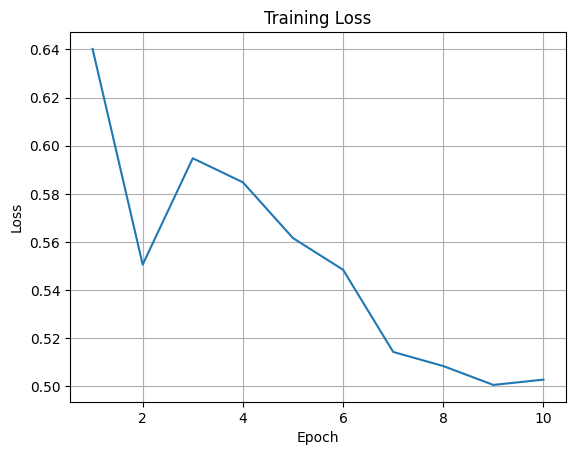

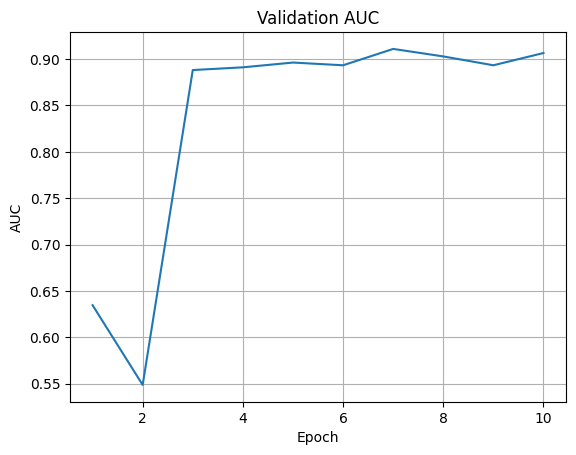

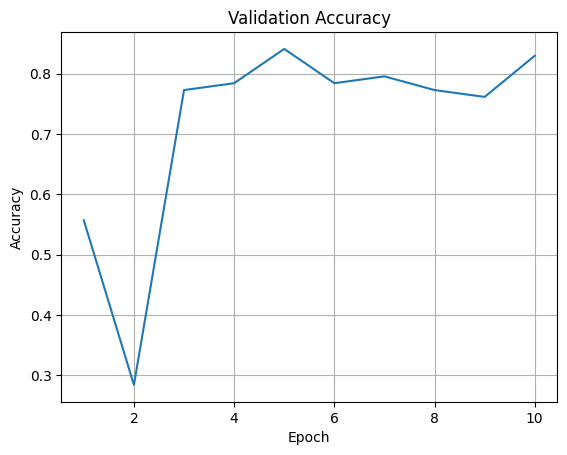

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# save metrics once
hist_df = pd.DataFrame(history)
csv_out = os.path.join(OUT_DIR, "training_history.csv")
hist_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)

def save_plot(x, y, title, ylab, filename):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.grid(True)
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=200, bbox_inches="tight")
    plt.show()

save_plot(hist_df["epoch"], hist_df["train_loss"], "Training Loss", "Loss", "curve_train_loss.png")
save_plot(hist_df["epoch"], hist_df["val_auc"], "Validation AUC", "AUC", "curve_val_auc.png")
save_plot(hist_df["epoch"], hist_df["val_acc"], "Validation Accuracy", "Accuracy", "curve_val_acc.png")

In [15]:
import pandas as pd
hist_df = pd.DataFrame(history)
csv_out = os.path.join(OUT_DIR, "training_history.csv")
hist_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)
hist_df

Saved: /content/work_oasis/outputs/training_history.csv


,epoch,train_loss,val_auc,val_acc
0,1,0.640198,0.634559,0.556818
1,2,0.550604,0.548529,0.284091
2,3,0.594780,0.888235,0.772727
3,4,0.584798,0.891176,0.784091
4,5,0.561634,0.896324,0.840909
5,6,0.548464,0.893382,0.784091
6,7,0.514343,0.911029,0.795455
7,8,0.508465,0.902941,0.772727
8,9,0.500635,0.893382,0.761364
9,10,0.502833,0.906618,0.829545


In [16]:
import os, glob
print("OUT_DIR =", OUT_DIR)
for f in sorted(glob.glob(os.path.join(OUT_DIR, "*"))):
    print(os.path.basename(f))

OUT_DIR = /content/work_oasis/outputs
README_results.txt
best_model.pt
curve_train_loss.png
curve_val_acc.png
curve_val_auc.png
training_history.csv


Threshold (Youden) = 0.1469
AUC=0.911  ACC=0.875  Precision=0.667  Recall=0.900  F1=0.766
Confusion matrix:
 [[59  9]
 [ 2 18]]
Saved: /content/work_oasis/outputs/val_predictions_best_threshold.csv


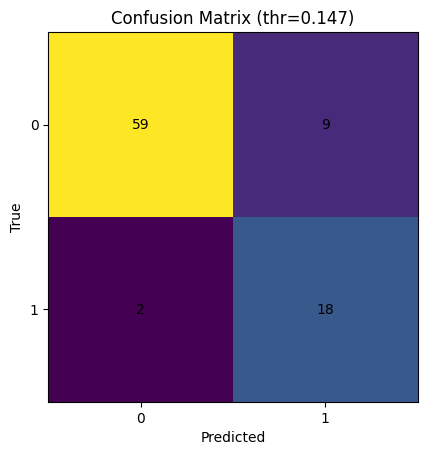

Saved: /content/work_oasis/outputs/confusion_matrix_best_threshold.png


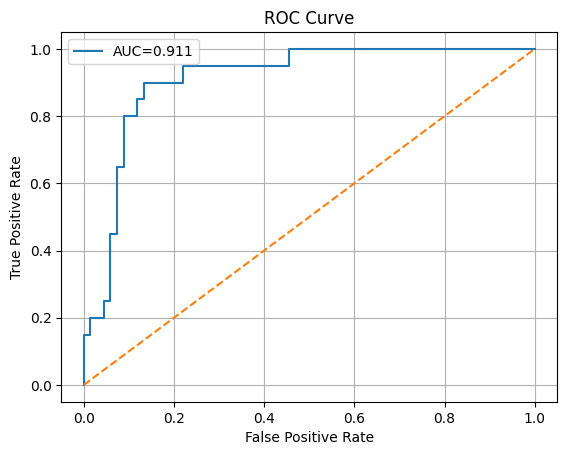

Saved: /content/work_oasis/outputs/roc_curve.png


{'threshold': 0.1468808799982071,
 'auc': 0.911029411764706,
 'acc': 0.875,
 'precision': 0.6666666666666666,
 'recall': 0.9,
 'f1': 0.7659574468085106,
 'cm': array([[59,  9],
        [ 2, 18]])}

In [17]:
# --- Evaluation + Best-threshold confusion matrix + ROC + saving artifacts ---
# Paste this as ONE cell (after you have: model, device, val_loader, OUT_DIR, and best_model already loaded)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc as sk_auc,
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)

def eval_best_threshold(model, val_loader, device, out_dir, force_threshold=None):
    model.eval()
    y_true, y_prob = [], []

    # 1) Collect probabilities
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)
            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())

    y_true = np.array(y_true, dtype=int)
    y_prob = np.array(y_prob, dtype=float)

    # 2) AUC (threshold-free)
    auc_val = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

    # 3) Choose threshold
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    if force_threshold is None:
        j = tpr - fpr  # Youden's J
        best_idx = int(np.argmax(j))
        best_thr = float(thr[best_idx])
        thr_name = "Youden"
    else:
        best_thr = float(force_threshold)
        thr_name = "Forced"

    # 4) Predictions with chosen threshold
    y_pred = (y_prob >= best_thr).astype(int)

    acc_val = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    print(f"Threshold ({thr_name}) = {best_thr:.4f}")
    print(f"AUC={auc_val:.3f}  ACC={acc_val:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print("Confusion matrix:\n", cm)

    # 5) Save predictions
    os.makedirs(out_dir, exist_ok=True)
    pred_df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob, "y_pred": y_pred})
    pred_path = os.path.join(out_dir, "val_predictions_best_threshold.csv")
    pred_df.to_csv(pred_path, index=False)
    print("Saved:", pred_path)

    # 6) Plot & save confusion matrix
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (thr={best_thr:.3f})")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks([0, 1]); plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    cm_path = os.path.join(out_dir, "confusion_matrix_best_threshold.png")
    plt.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)

    # 7) Plot & save ROC
    roc_auc_val = sk_auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    roc_path = os.path.join(out_dir, "roc_curve.png")
    plt.savefig(roc_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", roc_path)

    return {
        "threshold": best_thr,
        "auc": float(auc_val),
        "acc": float(acc_val),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "cm": cm,
    }

# Run evaluation (auto threshold by default)
results = eval_best_threshold(model, val_loader, device, OUT_DIR)
results

In [18]:
import json, os

summary = {
    "best_threshold": float(results["threshold"]),
    "auc": float(results["auc"]),
    "acc": float(results["acc"]),
    "precision": float(results["precision"]),
    "recall": float(results["recall"]),
    "f1": float(results["f1"]),
    "cm": results["cm"].tolist(),
}

out_path = os.path.join(OUT_DIR, "eval_summary.json")
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", out_path)
summary

Saved: /content/work_oasis/outputs/eval_summary.json


{'best_threshold': 0.1468808799982071,
 'auc': 0.911029411764706,
 'acc': 0.875,
 'precision': 0.6666666666666666,
 'recall': 0.9,
 'f1': 0.7659574468085106,
 'cm': [[59, 9], [2, 18]]}

In [19]:
print(df.columns.tolist())
print(df["ID"].head())

['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'CDR_num', 'label', 'ID_norm']
0    OAS1_0001_MR1
1    OAS1_0002_MR1
2    OAS1_0003_MR1
3    OAS1_0004_MR1
4    OAS1_0005_MR1
Name: ID, dtype: object


x1 shape: (1, 1, 128, 128, 128) label: 1


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  0%|          | 0/1000 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(se

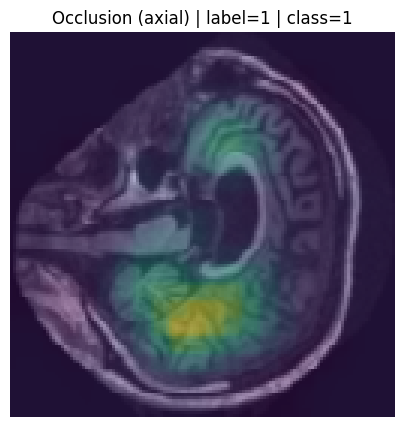

Saved: /content/work_oasis/outputs/occ_axial_z64.png


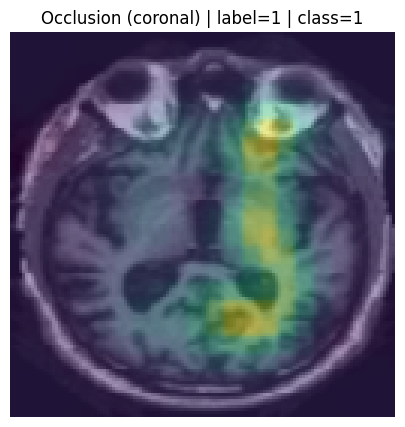

Saved: /content/work_oasis/outputs/occ_coronal_y64.png


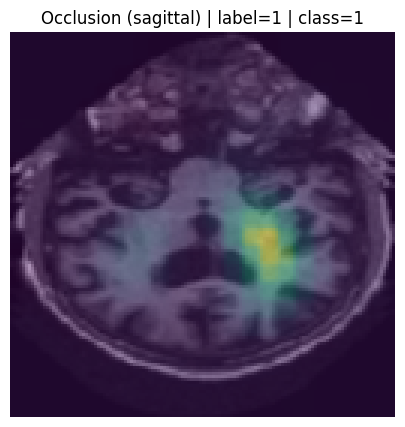

Saved: /content/work_oasis/outputs/occ_sagittal_x64.png
occ_map shape used: (128, 128, 128)
occ_logits shape: (1, 1, 128, 128, 128)


In [20]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.visualize import OcclusionSensitivity

# 1) get one sample
batch = next(iter(val_loader))
x = batch["image"].to(device)      # (B,C,H,W,D)
y = batch["label"].long().cpu().numpy()

x1 = x[0:1]
y1 = int(y[0])
print("x1 shape:", tuple(x1.shape), "label:", y1)

# 2) run occlusion sensitivity (NO extra kwargs!)
model.eval()
occ = OcclusionSensitivity(nn_module=model, mask_size=(16, 16, 16), n_batch=8)

with torch.no_grad():
    occ_map, occ_logits = occ(x1)   # <-- returns (map, logits) in your version

# occ_map is usually (1, C, H, W, D) or (1, H, W, D) depending on MONAI version
occ_map = occ_map.detach().float().cpu()
img = x1.detach().float().cpu()[0, 0]  # (H,W,D)

# ---- choose channel for "positive class"
# If occ_map has a class/channel dimension, we take channel 1.
# If it doesn't, we just use it directly.
if occ_map.ndim == 5:
    # (B,C,H,W,D) -> pick class 1 if available, else class 0
    if occ_map.shape[1] > 1:
        occ_map = occ_map[0, 1]
        target_class = 1
    else:
        occ_map = occ_map[0, 0]
        target_class = 0
elif occ_map.ndim == 4:
    occ_map = occ_map[0]
    target_class = 1  # just for title
else:
    raise ValueError("Unexpected occ_map shape: " + str(tuple(occ_map.shape)))

# 3) normalize for overlay
img_np = img.numpy()
occ_np = occ_map.numpy()
occ_np = occ_np - occ_np.min()
if occ_np.max() > 0:
    occ_np = occ_np / occ_np.max()

H, W, D = img_np.shape
z = D // 2
yidx = W // 2
xidx = H // 2

def save_overlay(name, base2d, heat2d, fname):
    plt.figure(figsize=(6, 5))
    plt.imshow(base2d, cmap="gray")
    plt.imshow(heat2d, alpha=0.45)
    plt.title(f"Occlusion ({name}) | label={y1} | class={target_class}")
    plt.axis("off")
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_overlay("axial",    img_np[:, :, z],    occ_np[:, :, z],    f"occ_axial_z{z}.png")
save_overlay("coronal",  img_np[:, yidx, :], occ_np[:, yidx, :], f"occ_coronal_y{yidx}.png")
save_overlay("sagittal", img_np[xidx, :, :], occ_np[xidx, :, :], f"occ_sagittal_x{xidx}.png")

print("occ_map shape used:", occ_np.shape)
print("occ_logits shape:", tuple(occ_logits.detach().cpu().shape))

Best slices -> axial z: 85 | coronal y: 68 | sagittal x: 86


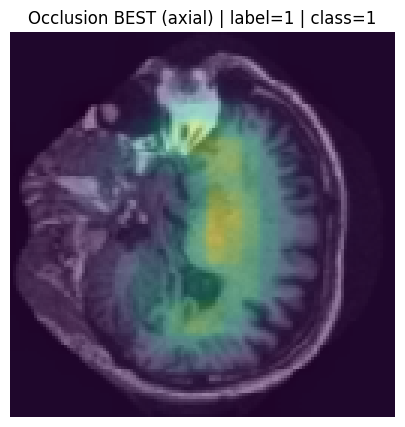

Saved: /content/work_oasis/outputs/occBEST_axial_z85.png


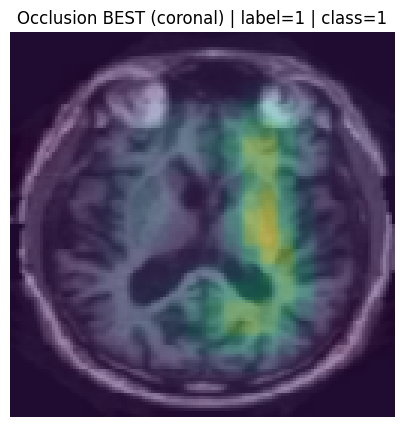

Saved: /content/work_oasis/outputs/occBEST_coronal_y68.png


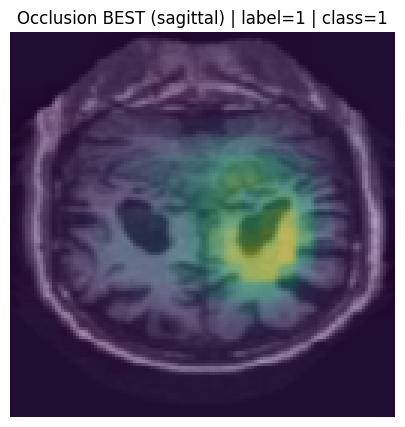

Saved: /content/work_oasis/outputs/occBEST_sagittal_x86.png


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

H, W, D = occ_np.shape

best_z = int(np.argmax([occ_np[:, :, z].mean() for z in range(D)]))  # axial
best_y = int(np.argmax([occ_np[:, y, :].mean() for y in range(W)]))  # coronal
best_x = int(np.argmax([occ_np[x, :, :].mean() for x in range(H)]))  # sagittal

print("Best slices -> axial z:", best_z, "| coronal y:", best_y, "| sagittal x:", best_x)

def save_overlay(name, base2d, heat2d, fname):
    plt.figure(figsize=(6, 5))
    plt.imshow(base2d, cmap="gray")
    plt.imshow(heat2d, alpha=0.45)
    plt.title(f"Occlusion BEST ({name}) | label={y1} | class={target_class}")
    plt.axis("off")
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_overlay("axial",    img_np[:, :, best_z],   occ_np[:, :, best_z],   f"occBEST_axial_z{best_z}.png")
save_overlay("coronal",  img_np[:, best_y, :],   occ_np[:, best_y, :],   f"occBEST_coronal_y{best_y}.png")
save_overlay("sagittal", img_np[best_x, :, :],   occ_np[best_x, :, :],   f"occBEST_sagittal_x{best_x}.png")

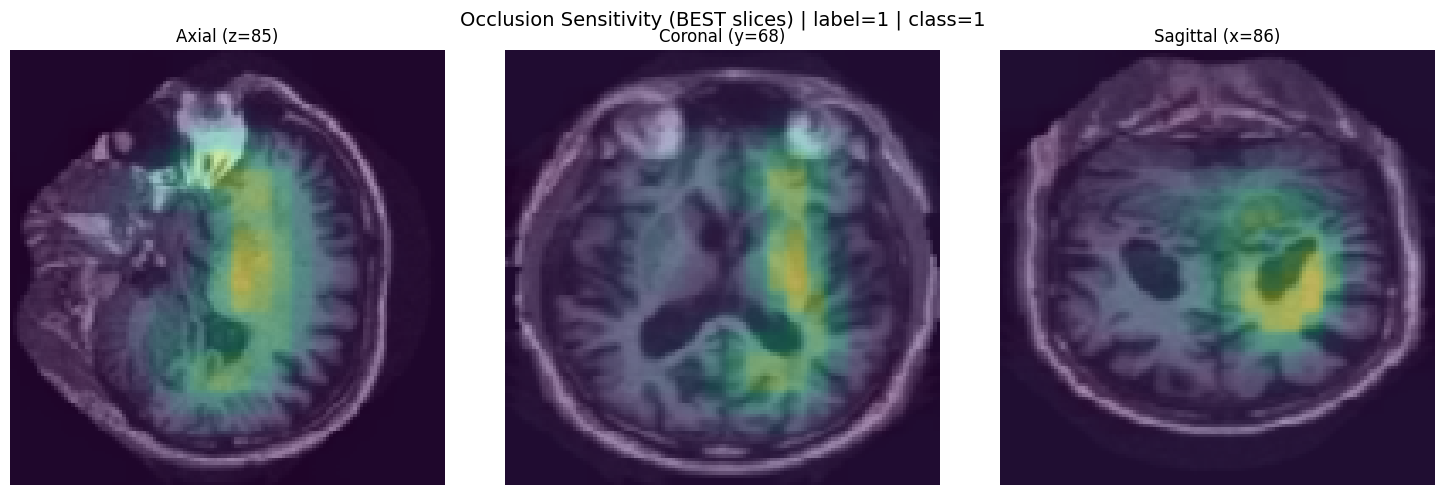

Saved combined figure: /content/work_oasis/outputs/occBEST_combined_x86_y68_z85.png


In [22]:
import os
import matplotlib.pyplot as plt

# Combined 3-view figure (best slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(img_np[:, :, best_z], cmap="gray")
axes[0].imshow(occ_np[:, :, best_z], alpha=0.45)
axes[0].set_title(f"Axial (z={best_z})")
axes[0].axis("off")

# Coronal
axes[1].imshow(img_np[:, best_y, :], cmap="gray")
axes[1].imshow(occ_np[:, best_y, :], alpha=0.45)
axes[1].set_title(f"Coronal (y={best_y})")
axes[1].axis("off")

# Sagittal
axes[2].imshow(img_np[best_x, :, :], cmap="gray")
axes[2].imshow(occ_np[best_x, :, :], alpha=0.45)
axes[2].set_title(f"Sagittal (x={best_x})")
axes[2].axis("off")

fig.suptitle(f"Occlusion Sensitivity (BEST slices) | label={y1} | class={target_class}", fontsize=14)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, f"occBEST_combined_x{best_x}_y{best_y}_z{best_z}.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined figure:", out_path)

In [23]:
import os, glob
print("OUT_DIR =", OUT_DIR)
for f in sorted(glob.glob(os.path.join(OUT_DIR, "occ*.png"))):
    print(os.path.basename(f))

OUT_DIR = /content/work_oasis/outputs
occBEST_axial_z85.png
occBEST_combined_x86_y68_z85.png
occBEST_coronal_y68.png
occBEST_sagittal_x86.png
occ_axial_z64.png
occ_coronal_y64.png
occ_sagittal_x64.png


Found negative sample: True


100%|██████████| 1000/1000 [06:48<00:00,  2.45it/s]


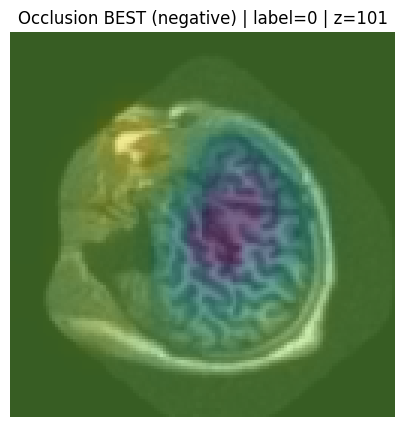

Saved: /content/work_oasis/outputs/occBEST_negative_axial_z101.png


In [24]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.visualize import OcclusionSensitivity

# find a negative sample
x0 = None
y0 = None
for b in val_loader:
    yy = b["label"].long().cpu().numpy()
    idxs = np.where(yy == 0)[0]
    if len(idxs) > 0:
        i = int(idxs[0])
        x0 = b["image"][i:i+1].to(device)
        y0 = 0
        break

print("Found negative sample:", x0 is not None)

model.eval()
occ = OcclusionSensitivity(nn_module=model, mask_size=(16,16,16), n_batch=8)

with torch.no_grad():
    occ_map0, _ = occ(x0)

occ_map0 = occ_map0.detach().float().cpu()
if occ_map0.ndim == 5:
    occ_map0 = occ_map0[0, 0]
else:
    occ_map0 = occ_map0[0]

img0 = x0.detach().float().cpu()[0,0].numpy()
heat0 = occ_map0.numpy()
heat0 = heat0 - heat0.min()
if heat0.max() > 0:
    heat0 = heat0 / heat0.max()

H,W,D = heat0.shape
z_lo, z_hi = int(0.2*D), int(0.8*D)
best_z0 = z_lo + int(np.argmax([heat0[:, :, z].mean() for z in range(z_lo, z_hi)]))

plt.figure(figsize=(6,5))
plt.imshow(img0[:,:,best_z0], cmap="gray")
plt.imshow(heat0[:,:,best_z0], alpha=0.45)
plt.title(f"Occlusion BEST (negative) | label=0 | z={best_z0}")
plt.axis("off")

outp = os.path.join(OUT_DIR, f"occBEST_negative_axial_z{best_z0}.png")
plt.savefig(outp, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outp)

In [25]:
import os, glob, json
import pandas as pd
from datetime import datetime

# ------------- helpers -------------
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

# ------------- collect what we have -------------
# Try to reuse existing variables if they exist
summary = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "task": "Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)",
    "dataset": "OASIS cross-sectional",
    "model": "MONAI DenseNet121 (3D), in_channels=1, out_channels=2",
    "out_dir": OUT_DIR,
}

# Pull best checkpoint info if available
best_model_path = os.path.join(OUT_DIR, "best_model.pt")
summary["best_model_path"] = best_model_path if os.path.exists(best_model_path) else None

# If you computed threshold metrics dict earlier, reuse it
# (you printed something like {'threshold':..., 'auc':..., 'acc':..., 'precision':..., 'recall':..., 'f1':..., 'cm':...})
if "metrics" in globals() and isinstance(metrics, dict):
    summary.update({
        "threshold": safe_float(metrics.get("threshold")),
        "val_auc": safe_float(metrics.get("auc")),
        "val_acc": safe_float(metrics.get("acc")),
        "precision": safe_float(metrics.get("precision")),
        "recall": safe_float(metrics.get("recall")),
        "f1": safe_float(metrics.get("f1")),
        "confusion_matrix": metrics.get("cm"),
    })
else:
    # fallback to common variable names if present
    for k, v in [
        ("val_auc", "val_auc"),
        ("val_acc", "val_acc"),
        ("threshold", "best_thr"),
        ("precision", "prec"),
        ("recall", "rec"),
        ("f1", "f1"),
    ]:
        if v in globals():
            summary[k] = safe_float(globals()[v])

# ------------- save summary files -------------
os.makedirs(OUT_DIR, exist_ok=True)

json_path = os.path.join(OUT_DIR, "metrics_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print("Saved:", json_path)

# CSV version (1-row)
csv_path = os.path.join(OUT_DIR, "metrics_summary.csv")
flat = summary.copy()
# flatten confusion matrix if exists
cm = flat.pop("confusion_matrix", None)
if isinstance(cm, (list, tuple)) or hasattr(cm, "shape"):
    try:
        import numpy as np
        cm = np.array(cm).tolist()
    except Exception:
        pass
flat["cm_00"] = cm[0][0] if isinstance(cm, list) else None
flat["cm_01"] = cm[0][1] if isinstance(cm, list) else None
flat["cm_10"] = cm[1][0] if isinstance(cm, list) else None
flat["cm_11"] = cm[1][1] if isinstance(cm, list) else None
pd.DataFrame([flat]).to_csv(csv_path, index=False)
print("Saved:", csv_path)

# ------------- manifest (everything in OUT_DIR) -------------
manifest_path = os.path.join(OUT_DIR, "outputs_manifest.txt")
files = sorted(glob.glob(os.path.join(OUT_DIR, "*")))
with open(manifest_path, "w") as f:
    for p in files:
        f.write(os.path.basename(p) + "\n")
print("Saved:", manifest_path)

# ------------- verify key artifacts -------------
expected = [
    "best_model.pt",
    "training_history.csv",
    "curve_train_loss.png",
    "curve_val_auc.png",
    "curve_val_acc.png",
    "confusion_matrix_best_threshold.png",
    "roc_curve.png",
    # interpretability (at least one combined + one negative)
    # names may vary, we check patterns
]
missing = [x for x in expected if not os.path.exists(os.path.join(OUT_DIR, x))]
print("\n=== CHECKLIST ===")
print("OUT_DIR:", OUT_DIR)
print("Missing exact-name files:", missing)

# Pattern checks
patterns = {
    "occlusion_combined": "occBEST_combined*.png",
    "occlusion_negative": "occBEST_negative*.png",
    "occlusion_positive": "occBEST_*axial*.png",
}
print("\n=== PATTERN CHECKS ===")
for name, pat in patterns.items():
    hits = sorted(glob.glob(os.path.join(OUT_DIR, pat)))
    print(f"{name}: {len(hits)} file(s)")
    if hits:
        print("  example:", os.path.basename(hits[0]))

# ------------- nice report text -------------
print("\n=== REPORT SUMMARY (copy/paste) ===")
print(f"Task: {summary['task']}")
if summary.get("val_auc") is not None: print(f"Validation AUC: {summary['val_auc']:.3f}")
if summary.get("val_acc") is not None: print(f"Validation Accuracy: {summary['val_acc']:.3f}")
if summary.get("threshold") is not None: print(f"Best threshold (Youden): {summary['threshold']:.3f}")
if summary.get("precision") is not None: print(f"Precision: {summary['precision']:.3f}")
if summary.get("recall") is not None: print(f"Recall: {summary['recall']:.3f}")
if summary.get("f1") is not None: print(f"F1: {summary['f1']:.3f}")
print("Artifacts saved to:", OUT_DIR)

Saved: /content/work_oasis/outputs/metrics_summary.json
Saved: /content/work_oasis/outputs/metrics_summary.csv
Saved: /content/work_oasis/outputs/outputs_manifest.txt

=== CHECKLIST ===
OUT_DIR: /content/work_oasis/outputs
Missing exact-name files: []

=== PATTERN CHECKS ===
occlusion_combined: 1 file(s)
  example: occBEST_combined_x86_y68_z85.png
occlusion_negative: 1 file(s)
  example: occBEST_negative_axial_z101.png
occlusion_positive: 2 file(s)
  example: occBEST_axial_z85.png

=== REPORT SUMMARY (copy/paste) ===
Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)
Artifacts saved to: /content/work_oasis/outputs


In [26]:
!zip -r oasis_results.zip /content/work_oasis/outputs

  adding: content/work_oasis/outputs/ (stored 0%)
  adding: content/work_oasis/outputs/occBEST_coronal_y68.png (deflated 13%)
  adding: content/work_oasis/outputs/occ_axial_z64.png (deflated 11%)
  adding: content/work_oasis/outputs/curve_val_acc.png (deflated 12%)
  adding: content/work_oasis/outputs/occ_sagittal_x64.png (deflated 11%)
  adding: content/work_oasis/outputs/metrics_summary.csv (deflated 33%)
  adding: content/work_oasis/outputs/occBEST_sagittal_x86.png (deflated 14%)
  adding: content/work_oasis/outputs/confusion_matrix_best_threshold.png (deflated 23%)
  adding: content/work_oasis/outputs/val_predictions_best_threshold.csv (deflated 57%)
  adding: content/work_oasis/outputs/eval_summary.json (deflated 41%)
  adding: content/work_oasis/outputs/curve_val_auc.png (deflated 15%)
  adding: content/work_oasis/outputs/curve_train_loss.png (deflated 12%)
  adding: content/work_oasis/outputs/occBEST_negative_axial_z101.png (deflated 19%)
  adding: content/work_oasis/outputs/REA

In [27]:
from google.colab import files
files.download("oasis_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-main.zip")
EXTRACT_DIR = Path("/content/ds005892")

assert ZIP_PATH.exists(), f"Zip file not found: {ZIP_PATH}"

# extract only once
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    print("Already extracted:", EXTRACT_DIR)

print("Top-level items:", [p.name for p in EXTRACT_DIR.iterdir()][:10])

Extracted to: /content/ds005892
Top-level items: ['ds005892-main']


In [30]:
from pathlib import Path

base = Path("/content/ds005892")

for p in base.iterdir():
    print(p)

/content/ds005892/ds005892-main


In [31]:
# ===== PD (OpenNeuro ds005892) CONFIG =====
import os, glob, random
import numpy as np
import pandas as pd
from pathlib import Path

PD_PROJECT_DIR = Path("/content/work_pd_ds005892")
PD_OUT_DIR = PD_PROJECT_DIR / "outputs"
PD_OUT_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: set this to where YOU uploaded ds005892 on Colab (or Google Drive)
# Example 1 (Colab upload): "/content/ds005892"
# Example 2 (Drive): "/content/drive/MyDrive/datasets/ds005892"
PD_DATA_ROOT = Path("/content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-download")

PD_CFG = {
    "project_name": "PD_ds005892_T1w_binary_PD_vs_Control",
    "seed": 42,
    "img_size": (128, 128, 128),
    "batch_size": 2,
    "num_workers": 2,
    "max_epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "out_dir": str(PD_OUT_DIR),
}

print("PD_DATA_ROOT:", PD_DATA_ROOT)
print("PD_OUT_DIR:", PD_OUT_DIR)

PD_DATA_ROOT: /content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-download
PD_OUT_DIR: /content/work_pd_ds005892/outputs


In [32]:
# ===== PD (ds005892) INDEXING =====

participants_tsv = PD_DATA_ROOT / "participants.tsv"
assert participants_tsv.exists(), f"Missing: {participants_tsv}"

PD_part = pd.read_csv(participants_tsv, sep="\t")
print("participants columns:", PD_part.columns.tolist())
print(PD_part.head())

# Normalize group labels
PD_part["group"] = PD_part["group"].astype(str).str.strip()

def make_label(g):
    if g.lower() == "control":
        return 0
    if g.upper().startswith("PD"):
        return 1
    return None

PD_part["label"] = PD_part["group"].apply(make_label)
PD_part = PD_part.dropna(subset=["label"]).copy()
PD_part["label"] = PD_part["label"].astype(int)

print("Group counts:")
print(PD_part["group"].value_counts())
print("Label counts:", PD_part["label"].value_counts().to_dict())

participants columns: ['participant_id', 'group', 'age', 'sex']
  participant_id    group  age sex
0     sub-MJF001   PD-MCI   68   M
1     sub-MJF002   PD-MCI   67   M
2     sub-MJF003  Control   68   M
3     sub-MJF006  Control   75   M
4     sub-MJF007   PD-MCI   77   M
Group counts:
group
Control    22
PD-NC      18
PD-MCI     15
Name: count, dtype: int64
Label counts: {1: 33, 0: 22}


In [33]:
# ===== find T1w NIfTI files =====
# We use anatomical T1w: sub-*/anat/*_T1w.nii.gz

records = []
missing = 0

for _, row in PD_part.iterrows():
    sub = row["participant_id"]
    label = int(row["label"])

    candidates = sorted(glob.glob(str(PD_DATA_ROOT / sub / "anat" / f"{sub}_T1w.nii.gz")))
    if len(candidates) == 0:
        missing += 1
        continue

    records.append({
        "image": candidates[0],
        "label": label,
        "subject": sub,
        "group": row["group"],
        "age": row.get("age", None),
        "sex": row.get("sex", None),
    })

print("Found records:", len(records), "| missing T1w:", missing)
assert len(records) > 10, "Too few T1w files found — check PD_DATA_ROOT path."

PD_df = pd.DataFrame(records)
PD_df.to_csv(PD_OUT_DIR / "pd_index.csv", index=False)
print("Saved:", PD_OUT_DIR / "pd_index.csv")
PD_df.head()

Found records: 55 | missing T1w: 0
Saved: /content/work_pd_ds005892/outputs/pd_index.csv


,image,label,subject,group,age,sex
0,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF001,PD-MCI,68,M
1,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF002,PD-MCI,67,M
2,/content/drive/MyDrive/Internship_MONAI/data_z...,0,sub-MJF003,Control,68,M
3,/content/drive/MyDrive/Internship_MONAI/data_z...,0,sub-MJF006,Control,75,M
4,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF007,PD-MCI,77,M


In [34]:
from sklearn.model_selection import train_test_split

PD_train_df, PD_val_df = train_test_split(
    PD_df,
    test_size=0.2,
    random_state=PD_CFG["seed"],
    stratify=PD_df["label"],
)

print("Train:", len(PD_train_df), "Val:", len(PD_val_df))
print("Train label dist:", PD_train_df["label"].value_counts().to_dict())
print("Val label dist:", PD_val_df["label"].value_counts().to_dict())

PD_train_files = PD_train_df[["image", "label"]].to_dict("records")
PD_val_files   = PD_val_df[["image", "label"]].to_dict("records")

Train: 44 Val: 11
Train label dist: {1: 26, 0: 18}
Val label dist: {1: 7, 0: 4}


In [35]:
# ===== PD transforms + datasets + loaders =====

import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    ResizeWithPadOrCropd,
    RandFlipd,
    RandAffined,
    EnsureTyped,
)
from monai.data import Dataset, DataLoader

PD_train_tfms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image"], source_key="image"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=PD_CFG["img_size"]),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"],
        prob=0.3,
        rotate_range=(0.05, 0.05, 0.05),
        translate_range=(5, 5, 5),
        scale_range=(0.05, 0.05, 0.05),
    ),
    EnsureTyped(keys=["image", "label"]),
])

PD_val_tfms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image"], source_key="image"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=PD_CFG["img_size"]),
    EnsureTyped(keys=["image", "label"]),
])

PD_train_ds = Dataset(data=PD_train_files, transform=PD_train_tfms)
PD_val_ds   = Dataset(data=PD_val_files, transform=PD_val_tfms)

PD_train_loader = DataLoader(
    PD_train_ds,
    batch_size=PD_CFG["batch_size"],
    shuffle=True,
    num_workers=PD_CFG["num_workers"],
)

PD_val_loader = DataLoader(
    PD_val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=PD_CFG["num_workers"],
)

print("PD loaders ready.")
print("Train batches:", len(PD_train_loader))
print("Val batches:", len(PD_val_loader))

PD loaders ready.
Train batches: 22
Val batches: 11


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [36]:
# ===== PD loader sanity check =====

first_batch = next(iter(PD_train_loader))
print("Keys:", first_batch.keys())
print("Image shape:", first_batch["image"].shape)
print("Label shape:", first_batch["label"].shape)
print("Labels:", first_batch["label"])

Keys: dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])
Image shape: torch.Size([2, 1, 128, 128, 128])
Label shape: torch.Size([2])
Labels: metatensor([0, 1])


In [37]:
# ===== PD model + training =====

import torch
import torch.nn as nn
from monai.networks.nets import DenseNet121
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PD_model = DenseNet121(
    spatial_dims=3,
    in_channels=1,
    out_channels=2
).to(device)

# class weights from train split
pd_train_labels = [d["label"] for d in PD_train_files]
pd_pos = sum(pd_train_labels)
pd_neg = len(pd_train_labels) - pd_pos

w0 = 1.0 / max(pd_neg, 1)
w1 = 1.0 / max(pd_pos, 1)
PD_class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

print("Train counts:", {0: pd_neg, 1: pd_pos}, "weights:", PD_class_weights.detach().cpu().numpy())

PD_loss_fn = nn.CrossEntropyLoss(weight=PD_class_weights)
PD_optimizer = torch.optim.AdamW(
    PD_model.parameters(),
    lr=PD_CFG["lr"],
    weight_decay=PD_CFG["weight_decay"]
)

PD_scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def pd_run_eval():
    PD_model.eval()
    y_true, y_prob, y_pred = [], [], []

    with torch.no_grad():
        for batch in PD_val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)

            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = PD_model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
                pred = torch.argmax(logits, dim=1)

            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())

    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan")
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    return auc, acc

PD_history = {"epoch": [], "train_loss": [], "val_auc": [], "val_acc": []}

PD_best_auc = -1.0
PD_best_path = PD_OUT_DIR / "best_model_pd.pt"

for epoch in range(1, PD_CFG["max_epochs"] + 1):
    PD_model.train()
    epoch_loss = 0.0

    pbar = tqdm(PD_train_loader, desc=f"[PD] Epoch {epoch}/{PD_CFG['max_epochs']}")
    for batch in pbar:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        PD_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = PD_model(x)
            loss = PD_loss_fn(logits, y)

        PD_scaler.scale(loss).backward()
        PD_scaler.step(PD_optimizer)
        PD_scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / max(1, len(PD_train_loader))
    val_auc, val_acc = pd_run_eval()

    PD_history["epoch"].append(epoch)
    PD_history["train_loss"].append(float(avg_loss))
    PD_history["val_auc"].append(float(val_auc) if val_auc == val_auc else float("nan"))
    PD_history["val_acc"].append(float(val_acc))

    print(f"[PD Epoch {epoch}] loss={avg_loss:.4f} val_auc={val_auc:.4f} val_acc={val_acc:.4f}")

    if val_auc == val_auc and val_auc > PD_best_auc:
        PD_best_auc = val_auc
        torch.save(
            {
                "model": PD_model.state_dict(),
                "epoch": int(epoch),
                "val_auc": float(val_auc),
            },
            PD_best_path,
        )
        print("Saved best:", PD_best_path)

print("Training finished. Best AUC:", PD_best_auc)

Device: cuda
Train counts: {0: 18, 1: 26} weights: [0.05555556 0.03846154]


[PD] Epoch 1/10: 100%|██████████| 22/22 [01:25<00:00,  3.89s/it, loss=0.7854]


[PD Epoch 1] loss=0.7185 val_auc=0.1071 val_acc=0.6364
Saved best: /content/work_pd_ds005892/outputs/best_model_pd.pt


[PD] Epoch 2/10: 100%|██████████| 22/22 [00:38<00:00,  1.73s/it, loss=0.9595]


[PD Epoch 2] loss=0.7130 val_auc=0.2143 val_acc=0.6364
Saved best: /content/work_pd_ds005892/outputs/best_model_pd.pt


...

[PD Epoch 8] loss=0.6320 val_auc=0.9286 val_acc=0.7273


[PD] Epoch 9/10: 100%|██████████| 22/22 [00:37<00:00,  1.71s/it, loss=0.6179]


[PD Epoch 9] loss=0.5760 val_auc=0.8571 val_acc=0.7273


[PD] Epoch 10/10: 100%|██████████| 22/22 [00:37<00:00,  1.69s/it, loss=0.8339]


[PD Epoch 10] loss=0.5506 val_auc=0.7143 val_acc=0.6364
Training finished. Best AUC: 0.9285714285714286


Saved: /content/work_pd_ds005892/outputs/pd_training_history.csv


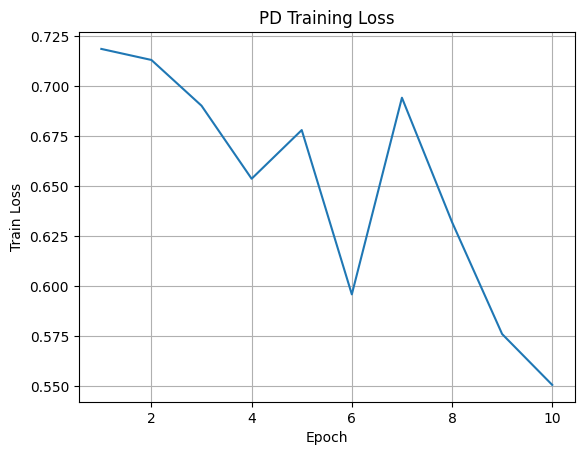

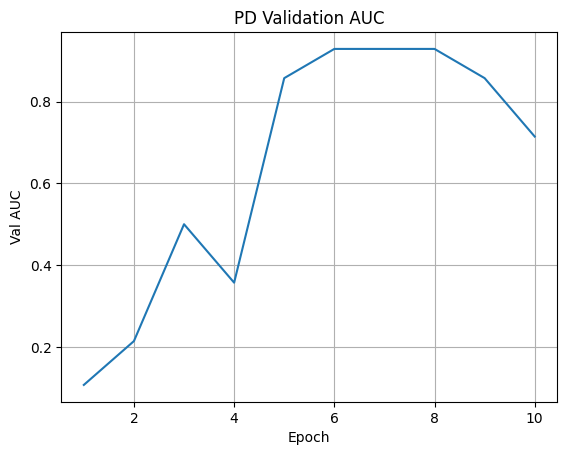

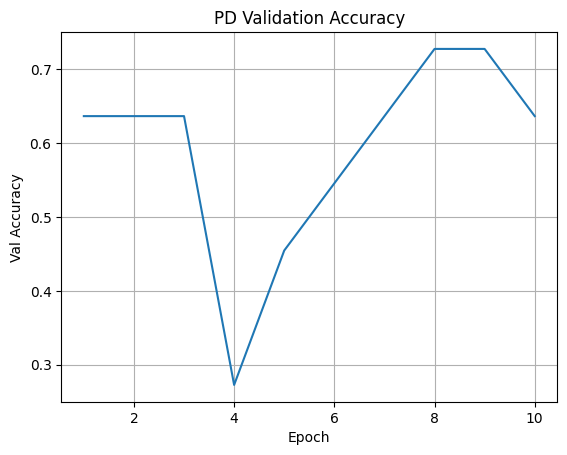

In [38]:
# ===== PD save curves =====

import pandas as pd
import matplotlib.pyplot as plt

PD_hist_df = pd.DataFrame(PD_history)
PD_hist_csv = PD_OUT_DIR / "pd_training_history.csv"
PD_hist_df.to_csv(PD_hist_csv, index=False)
print("Saved:", PD_hist_csv)

# train loss
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("PD Training Loss")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_train_loss.png", dpi=200, bbox_inches="tight")
plt.show()

# val auc
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Val AUC")
plt.title("PD Validation AUC")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_val_auc.png", dpi=200, bbox_inches="tight")
plt.show()

# val acc
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["val_acc"])
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("PD Validation Accuracy")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_val_acc.png", dpi=200, bbox_inches="tight")
plt.show()

Loaded best PD epoch: 6 best AUC: 0.9285714285714286

=== PD METRICS ===
AUC: 0.9285714285714286
ACC: 0.9090909090909091
Best threshold: 0.0004263746668584645
Precision: 0.875
Recall: 1.0
F1: 0.9333333333333333
Confusion matrix:
 [[3 1]
 [0 7]]
Saved: /content/work_pd_ds005892/outputs/pd_val_predictions.csv
Saved: /content/work_pd_ds005892/outputs/pd_metrics_summary.json
Saved: /content/work_pd_ds005892/outputs/pd_metrics_summary.csv


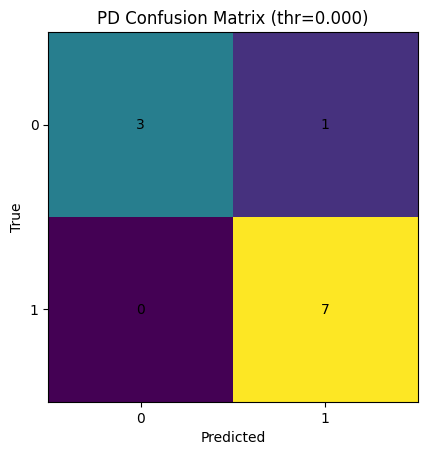

Saved: /content/work_pd_ds005892/outputs/pd_confusion_matrix.png


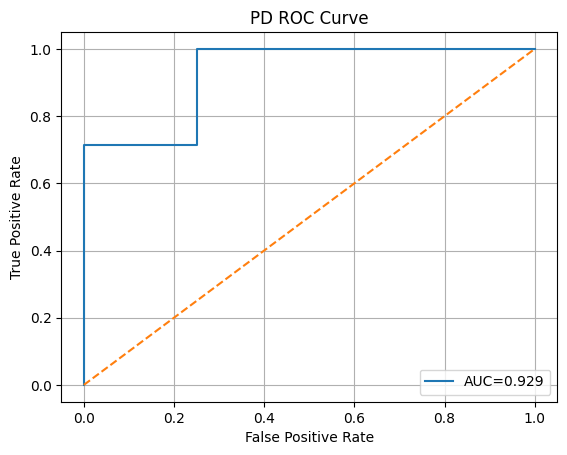

Saved: /content/work_pd_ds005892/outputs/pd_roc_curve.png


In [39]:
# ===== PD evaluation: confusion matrix + ROC + saved predictions =====

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc as sk_auc,
    roc_auc_score,
    accuracy_score,
    precision_recall_fscore_support,
)

# 1) load best checkpoint
pd_ckpt = torch.load(PD_best_path, map_location=device)
PD_model.load_state_dict(pd_ckpt["model"])
PD_model.eval()

print("Loaded best PD epoch:", pd_ckpt["epoch"], "best AUC:", pd_ckpt["val_auc"])

# 2) collect validation predictions
pd_y_true, pd_y_prob = [], []

with torch.no_grad():
    for batch in PD_val_loader:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = PD_model(x)
            prob1 = torch.softmax(logits, dim=1)[:, 1]

        pd_y_true.extend(y.detach().cpu().numpy().tolist())
        pd_y_prob.extend(prob1.detach().cpu().numpy().tolist())

pd_y_true = np.array(pd_y_true, dtype=int)
pd_y_prob = np.array(pd_y_prob, dtype=float)

# 3) best threshold by Youden J
pd_fpr, pd_tpr, pd_thr = roc_curve(pd_y_true, pd_y_prob)
pd_j = pd_tpr - pd_fpr
pd_best_idx = int(np.argmax(pd_j))
pd_best_thr = float(pd_thr[pd_best_idx])

pd_y_pred = (pd_y_prob >= pd_best_thr).astype(int)

# 4) metrics
pd_auc = float(roc_auc_score(pd_y_true, pd_y_prob)) if len(np.unique(pd_y_true)) > 1 else float("nan")
pd_acc = float(accuracy_score(pd_y_true, pd_y_pred))
pd_prec, pd_rec, pd_f1, _ = precision_recall_fscore_support(
    pd_y_true, pd_y_pred, average="binary", zero_division=0
)

pd_cm = confusion_matrix(pd_y_true, pd_y_pred)

print("\n=== PD METRICS ===")
print("AUC:", pd_auc)
print("ACC:", pd_acc)
print("Best threshold:", pd_best_thr)
print("Precision:", float(pd_prec))
print("Recall:", float(pd_rec))
print("F1:", float(pd_f1))
print("Confusion matrix:\n", pd_cm)

# 5) save predictions
pd_pred_path = PD_OUT_DIR / "pd_val_predictions.csv"
pd.DataFrame({
    "y_true": pd_y_true,
    "y_prob": pd_y_prob,
    "y_pred": pd_y_pred,
}).to_csv(pd_pred_path, index=False)
print("Saved:", pd_pred_path)

# 6) save metrics summary
pd_summary = {
    "task": "Parkinson vs Control using OpenNeuro ds005892 T1w MRI",
    "val_auc": pd_auc,
    "val_acc": pd_acc,
    "threshold_youden": pd_best_thr,
    "precision": float(pd_prec),
    "recall": float(pd_rec),
    "f1": float(pd_f1),
    "confusion_matrix": pd_cm.tolist(),
}

with open(PD_OUT_DIR / "pd_metrics_summary.json", "w") as f:
    json.dump(pd_summary, f, indent=2)

pd.DataFrame([{
    "task": pd_summary["task"],
    "val_auc": pd_summary["val_auc"],
    "val_acc": pd_summary["val_acc"],
    "threshold_youden": pd_summary["threshold_youden"],
    "precision": pd_summary["precision"],
    "recall": pd_summary["recall"],
    "f1": pd_summary["f1"],
    "tn": int(pd_cm[0, 0]),
    "fp": int(pd_cm[0, 1]),
    "fn": int(pd_cm[1, 0]),
    "tp": int(pd_cm[1, 1]),
}]).to_csv(PD_OUT_DIR / "pd_metrics_summary.csv", index=False)

print("Saved:", PD_OUT_DIR / "pd_metrics_summary.json")
print("Saved:", PD_OUT_DIR / "pd_metrics_summary.csv")

# 7) confusion matrix plot
plt.figure()
plt.imshow(pd_cm)
plt.title(f"PD Confusion Matrix (thr={pd_best_thr:.3f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1])
plt.yticks([0, 1])
for (i, j), v in np.ndenumerate(pd_cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.savefig(PD_OUT_DIR / "pd_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", PD_OUT_DIR / "pd_confusion_matrix.png")

# 8) ROC plot
plt.figure()
pd_roc_auc = float(sk_auc(pd_fpr, pd_tpr))
plt.plot(pd_fpr, pd_tpr, label=f"AUC={pd_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PD ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", PD_OUT_DIR / "pd_roc_curve.png")

In [40]:
# ===== PD package results for download =====

import shutil
from google.colab import files

PD_ZIP = "/content/pd_results.zip"

shutil.make_archive(
    PD_ZIP.replace(".zip",""),
    'zip',
    PD_OUT_DIR
)

print("Created:", PD_ZIP)

files.download(PD_ZIP)

Created: /content/pd_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 40.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagecodecs 2026.3.6 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have n

True label: 0


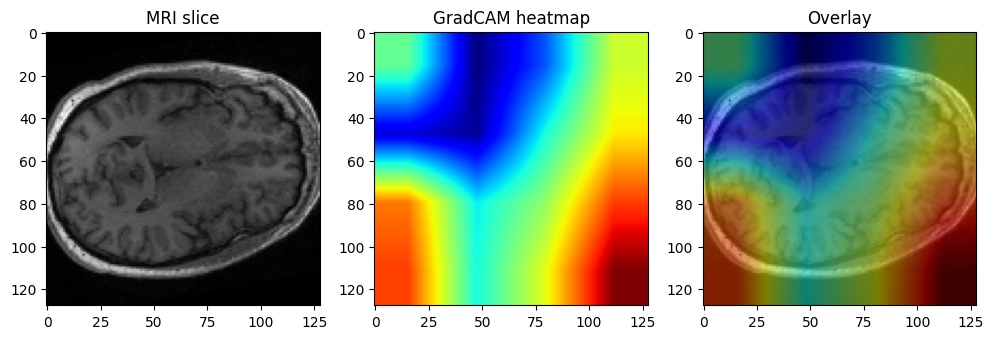

Saved: /content/work_pd_ds005892/outputs/pd_gradcam_example.png


In [42]:
# ===== PD Grad-CAM explainability =====

import torch
import matplotlib.pyplot as plt
import numpy as np

from monai.visualize import GradCAM

PD_model.eval()

# choose one validation sample
sample = next(iter(PD_val_loader))

image = sample["image"].to(device)
label = sample["label"].item()

print("True label:", label)

# choose last convolution layer
target_layer = "features.denseblock4"

cam = GradCAM(
    nn_module=PD_model,
    target_layers=target_layer,
)

heatmap = cam(x=image)

heatmap = heatmap.cpu().numpy()[0,0]
image_np = image.cpu().numpy()[0,0]

# take middle slice
z = image_np.shape[2] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np[:,:,z], cmap="gray")
plt.title("MRI slice")

plt.subplot(1,3,2)
plt.imshow(heatmap[:,:,z], cmap="jet")
plt.title("GradCAM heatmap")

plt.subplot(1,3,3)
plt.imshow(image_np[:,:,z], cmap="gray")
plt.imshow(heatmap[:,:,z], cmap="jet", alpha=0.5)
plt.title("Overlay")

plt.savefig(PD_OUT_DIR / "pd_gradcam_example.png", dpi=200)
plt.show()

print("Saved:", PD_OUT_DIR / "pd_gradcam_example.png")

In [43]:
# ===== Generate multiple GradCAM examples =====

import os
from tqdm import tqdm

save_dir = PD_OUT_DIR / "gradcam_examples"
os.makedirs(save_dir, exist_ok=True)

cam = GradCAM(
    nn_module=PD_model,
    target_layers="features.denseblock4"
)

count = 0

for batch in PD_val_loader:

    image = batch["image"].to(device)
    label = batch["label"].item()

    heatmap = cam(x=image)

    heatmap = heatmap.cpu().numpy()[0,0]
    image_np = image.cpu().numpy()[0,0]

    z = image_np.shape[2] // 2

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(image_np[:,:,z], cmap="gray")
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(heatmap[:,:,z], cmap="jet")
    plt.title("GradCAM")

    plt.subplot(1,3,3)
    plt.imshow(image_np[:,:,z], cmap="gray")
    plt.imshow(heatmap[:,:,z], cmap="jet", alpha=0.5)
    plt.title("Overlay")

    path = save_dir / f"gradcam_{count}_label{label}.png"
    plt.savefig(path, dpi=200)
    plt.close()

    count += 1

    if count >= 10:
        break

print("Saved GradCAM examples to:", save_dir)

Saved GradCAM examples to: /content/work_pd_ds005892/outputs/gradcam_examples


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

MSSEG_ZIP = "/content/drive/MyDrive/Internship_MONAI/data_zips/MSSEG2016/training/= MSSEG-Training.zip"
MSSEG_ROOT = "/content/msseg"

os.makedirs(MSSEG_ROOT, exist_ok=True)

print("Zip file:", MSSEG_ZIP)
print("Zip exists:", os.path.exists(MSSEG_ZIP))
print("Extraction folder:", MSSEG_ROOT)

Zip file: /content/drive/MyDrive/Internship_MONAI/data_zips/MSSEG2016/training/= MSSEG-Training.zip
Zip exists: True
Extraction folder: /content/msseg


In [3]:
import zipfile

with zipfile.ZipFile(MSSEG_ZIP, "r") as zip_ref:
    zip_ref.extractall(MSSEG_ROOT)

print("Extraction finished")

Extraction finished


In [4]:
import os

print("Top-level extracted items:")
print(os.listdir(MSSEG_ROOT))

Top-level extracted items:
['__MACOSX', 'Training']


In [5]:
for root, dirs, files in os.walk(MSSEG_ROOT):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-" * 50)
    break

ROOT: /content/msseg
DIRS: ['__MACOSX', 'Training']
FILES: []
--------------------------------------------------


In [6]:
# ===== MSSEG centers and patients =====

import os

TRAIN_PATH = "/content/msseg/Training"

centers = sorted([
    c for c in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, c))
])

print("Centers:", centers)

for center in centers:
    center_path = os.path.join(TRAIN_PATH, center)
    patients = sorted([
        p for p in os.listdir(center_path)
        if os.path.isdir(os.path.join(center_path, p))
    ])
    print(center, "->", len(patients), "patients")
    print(" first few:", patients[:3])

Centers: ['Center_01', 'Center_07', 'Center_08']
Center_01 -> 5 patients
 first few: ['Patient_01', 'Patient_02', 'Patient_03']
Center_07 -> 5 patients
 first few: ['Patient_01', 'Patient_02', 'Patient_03']
Center_08 -> 5 patients
 first few: ['Patient_01', 'Patient_02', 'Patient_03']


In [8]:
# ===== Print all files from one patient for debugging =====

for center in centers:
    center_path = os.path.join(TRAIN_PATH, center)
    patients = sorted([
        p for p in os.listdir(center_path)
        if os.path.isdir(os.path.join(center_path, p))
    ])
    if len(patients) > 0:
        patient_path = os.path.join(center_path, patients[0])
        print("DEBUG patient path:", patient_path)
        for f in os.listdir(patient_path):
            print(f)
        break

DEBUG patient path: /content/msseg/Training/Center_01/Patient_01
Raw_Data
Preprocessed_Data
.DS_Store
Masks


In [9]:
# ===== Inspect MSSEG patient subfolders =====

import os

patient_path = "/content/msseg/Training/Center_01/Patient_01"

for sub in ["Raw_Data", "Preprocessed_Data", "Masks"]:
    sub_path = os.path.join(patient_path, sub)
    print(f"\n{sub} ->", os.path.exists(sub_path))
    if os.path.exists(sub_path):
        files = sorted(os.listdir(sub_path))
        print("count:", len(files))
        print("first files:", files[:20])


Raw_Data -> True
count: 5
first files: ['DP.nii.gz', 'FLAIR.nii.gz', 'GADO.nii.gz', 'T1.nii.gz', 'T2.nii.gz']

Preprocessed_Data -> True
count: 5
first files: ['DP_preprocessed.nii.gz', 'FLAIR_preprocessed.nii.gz', 'GADO_preprocessed.nii.gz', 'T1_preprocessed.nii.gz', 'T2_preprocessed.nii.gz']

Masks -> True
count: 9
first files: ['Brain_Mask.nii.gz', 'Consensus.nii.gz', 'ManualSegmentation_1.nii.gz', 'ManualSegmentation_2.nii.gz', 'ManualSegmentation_3.nii.gz', 'ManualSegmentation_4.nii.gz', 'ManualSegmentation_5.nii.gz', 'ManualSegmentation_6.nii.gz', 'ManualSegmentation_7.nii.gz']


In [10]:
# ===== Build MSSEG multimodal data list =====

import os

data_dicts = []

for center in centers:
    center_path = os.path.join(TRAIN_PATH, center)

    patients = sorted([
        p for p in os.listdir(center_path)
        if os.path.isdir(os.path.join(center_path, p))
    ])

    for patient in patients:
        patient_path = os.path.join(center_path, patient)

        img_dir = os.path.join(patient_path, "Preprocessed_Data")
        mask_dir = os.path.join(patient_path, "Masks")

        if not (os.path.isdir(img_dir) and os.path.isdir(mask_dir)):
            continue

        img_files = sorted(os.listdir(img_dir))
        mask_files = sorted(os.listdir(mask_dir))

        def find_one(keyword):
            hits = [
                os.path.join(img_dir, f)
                for f in img_files
                if keyword in f.lower() and f.endswith(".nii.gz")
            ]
            return hits[0] if len(hits) > 0 else None

        flair = find_one("flair")
        t1    = find_one("t1")
        t2    = find_one("t2")
        dp    = find_one("dp")

        consensus_candidates = [
            os.path.join(mask_dir, f)
            for f in mask_files
            if ("consensus" in f.lower()) and f.endswith(".nii.gz")
        ]
        consensus = consensus_candidates[0] if len(consensus_candidates) > 0 else None

        if all(x is not None for x in [flair, t1, t2, dp, consensus]):
            data_dicts.append({
                "image": [flair, t1, t2, dp],
                "label": consensus,
                "center": center,
                "patient": patient,
            })

print("Total multimodal usable cases:", len(data_dicts))
print("First case:", data_dicts[0] if len(data_dicts) > 0 else "None")

Total multimodal usable cases: 15
First case: {'image': ['/content/msseg/Training/Center_01/Patient_01/Preprocessed_Data/FLAIR_preprocessed.nii.gz', '/content/msseg/Training/Center_01/Patient_01/Preprocessed_Data/T1_preprocessed.nii.gz', '/content/msseg/Training/Center_01/Patient_01/Preprocessed_Data/T2_preprocessed.nii.gz', '/content/msseg/Training/Center_01/Patient_01/Preprocessed_Data/DP_preprocessed.nii.gz'], 'label': '/content/msseg/Training/Center_01/Patient_01/Masks/Consensus.nii.gz', 'center': 'Center_01', 'patient': 'Patient_01'}


In [11]:
from sklearn.model_selection import KFold

print("Number of usable cases:", len(data_dicts))

if len(data_dicts) < 3:
    raise ValueError(
        f"Need at least 3 samples for 3-fold CV, but found {len(data_dicts)}. "
        "Run the data-building cell first and verify file matching."
    )

num_folds = 3
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

fold_splits = []
for fold_id, (train_idx, val_idx) in enumerate(kf.split(data_dicts), start=1):
    train_fold = [data_dicts[i] for i in train_idx]
    val_fold = [data_dicts[i] for i in val_idx]
    print(f"Fold {fold_id}: train={len(train_fold)}, val={len(val_fold)}")
    fold_splits.append((train_fold, val_fold))

Number of usable cases: 15
Fold 1: train=10, val=5
Fold 2: train=10, val=5
Fold 3: train=10, val=5


In [12]:
# ===== Train / validation split =====

from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    data_dicts,
    test_size=0.2,
    random_state=42
)

print("Train cases:", len(train_files))
print("Val cases:", len(val_files))

Train cases: 12
Val cases: 3


In [13]:
# ===== MSSEG multimodal transforms =====

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    DivisiblePadd,
    RandCropByPosNegLabeld,
    EnsureTyped,
)

ms_train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest")
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    DivisiblePadd(keys=["image", "label"], k=16),
    RandCropByPosNegLabeld(
        keys=["image","label"],
        label_key="label",
        spatial_size=(96,96,96),
        pos=2,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
    EnsureTyped(keys=["image", "label"]),
])

ms_val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest")
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    DivisiblePadd(keys=["image", "label"], k=16),
    EnsureTyped(keys=["image", "label"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [14]:
# ===== MSSEG datasets and loaders =====

from monai.data import Dataset, DataLoader

ms_train_ds = Dataset(data=train_files, transform=ms_train_transforms)
ms_val_ds = Dataset(data=val_files, transform=ms_val_transforms)

ms_train_loader = DataLoader(
    ms_train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

ms_val_loader = DataLoader(
    ms_val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
)

print("MS train batches:", len(ms_train_loader))
print("MS val batches:", len(ms_val_loader))

MS train batches: 12
MS val batches: 3


In [15]:
# ===== MSSEG multimodal loader sanity check =====

first_batch = next(iter(ms_train_loader))

print("Keys:", first_batch.keys())
print("Image shape:", first_batch["image"].shape)
print("Label shape:", first_batch["label"].shape)
print("Label unique values:", first_batch["label"].unique())

Keys: dict_keys(['image', 'label', 'center', 'patient', 'foreground_start_coord', 'foreground_end_coord'])
Image shape: torch.Size([4, 4, 96, 96, 96])
Label shape: torch.Size([4, 1, 96, 96, 96])
Label unique values: metatensor([0., 1.])


In [16]:
# ===== MSSEG config / outputs =====

import os
import torch

MS_OUT_DIR = "/content/work_msseg/outputs"
os.makedirs(MS_OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("MS outputs:", MS_OUT_DIR)

Device: cuda
MS outputs: /content/work_msseg/outputs


In [17]:
# ===== MSSEG 3D UNet (4-channel) =====

from monai.networks.nets import UNet

ms_model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

print(ms_model.__class__.__name__)

UNet


In [18]:
# ===== improved loss / optimizer / metric =====

import torch
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete
from monai.data import decollate_batch
from monai.losses import DiceFocalLoss


ms_loss_fn = DiceFocalLoss(
    sigmoid=True,
    lambda_dice=0.7,
    lambda_focal=0.3
)
ms_optimizer = torch.optim.Adam(ms_model.parameters(), lr=1e-4, weight_decay=1e-5)

ms_dice_metric = DiceMetric(include_background=True, reduction="mean")

ms_post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
ms_post_label = Compose([AsDiscrete(threshold=0.5)])

print("Improved MS loss ready.")

Improved MS loss ready.


In [19]:
# ===== validation function =====

import torch
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

def ms_validate(model, val_loader, metric):
    model.eval()
    metric.reset()

    with torch.no_grad():
        for batch in val_loader:
            val_images = batch["image"].to(device)
            val_labels = batch["label"].to(device)

            # sliding window inference with patch size divisible by 16
            val_outputs = sliding_window_inference(
                inputs=val_images,
                roi_size=(96, 96, 96),
                sw_batch_size=1,
                predictor=model,
                overlap=0.25,
            )

            val_outputs_list = [ms_post_pred(i) for i in decollate_batch(val_outputs)]
            val_labels_list = [ms_post_label(i) for i in decollate_batch(val_labels)]

            metric(y_pred=val_outputs_list, y=val_labels_list)

    mean_dice = metric.aggregate().item()
    metric.reset()
    return mean_dice

In [21]:
# ===== MSSEG training loop =====

from tqdm import tqdm
import pandas as pd

ms_best_path = os.path.join(MS_OUT_DIR, "best_msseg_unet.pt")
ms_max_epochs = 60
ms_best_dice = -1
ms_best_epoch = -1
ms_hist_csv = os.path.join(MS_OUT_DIR, "msseg_training_history_4ch.csv")

ms_history = []

for epoch in range(ms_max_epochs):
    ms_model.train()
    epoch_loss = 0
    step = 0

    pbar = tqdm(ms_train_loader, desc=f"[MS Epoch {epoch+1}/{ms_max_epochs}]")

    for batch in pbar:
        step += 1

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        ms_optimizer.zero_grad()
        outputs = ms_model(images)
        loss = ms_loss_fn(outputs, labels)
        loss.backward()
        ms_optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss /= step

    val_dice = ms_validate(ms_model, ms_val_loader, ms_dice_metric)

    ms_history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "val_dice": val_dice,
    })

    print(f"[MS Epoch {epoch+1}] train_loss={epoch_loss:.4f} val_dice={val_dice:.4f}")

    if val_dice > ms_best_dice:
        ms_best_dice = val_dice
        ms_best_epoch = epoch + 1

        torch.save({
            "epoch": ms_best_epoch,
            "model_state_dict": ms_model.state_dict(),
            "val_dice": ms_best_dice,
        }, ms_best_path)

        print("Saved best model:", ms_best_path)

print("Training finished.")
print("Best val Dice:", ms_best_dice, "at epoch", ms_best_epoch)

ms_hist_df = pd.DataFrame(ms_history)
ms_hist_csv = os.path.join(MS_OUT_DIR, "msseg_training_history.csv")
ms_hist_df.to_csv(ms_hist_csv, index=False)
print("Saved history:", ms_hist_csv)

[MS Epoch 1/60]: 100%|██████████| 12/12 [01:23<00:00,  6.96s/it, loss=0.781]


[MS Epoch 1] train_loss=0.7713 val_dice=0.0142
Saved best model: /content/work_msseg/outputs/best_msseg_unet.pt


[MS Epoch 2/60]: 100%|██████████| 12/12 [01:25<00:00,  7.14s/it, loss=0.759]


[MS Epoch 2] train_loss=0.7617 val_dice=0.0147
Saved best model: /content/work_msseg/outputs/best_msseg_unet.pt


[MS Epoch 3/60]: 100%|██████████| 12/12 [01:16<00:00,  6.40s/it, loss=0.737]


...

[MS Epoch 58] train_loss=0.7304 val_dice=0.0297
Saved best model: /content/work_msseg/outputs/best_msseg_unet.pt


[MS Epoch 59/60]: 100%|██████████| 12/12 [01:16<00:00,  6.36s/it, loss=0.708]


[MS Epoch 59] train_loss=0.7313 val_dice=0.0297


[MS Epoch 60/60]: 100%|██████████| 12/12 [01:14<00:00,  6.22s/it, loss=0.754]


[MS Epoch 60] train_loss=0.7301 val_dice=0.0292
Training finished.
Best val Dice: 0.029701635241508484 at epoch 58
Saved history: /content/work_msseg/outputs/msseg_training_history.csv


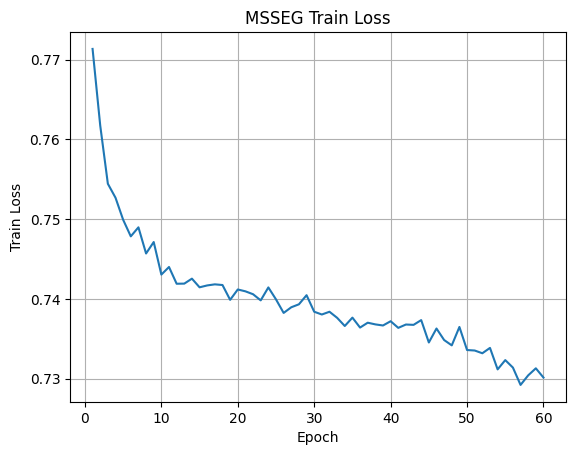

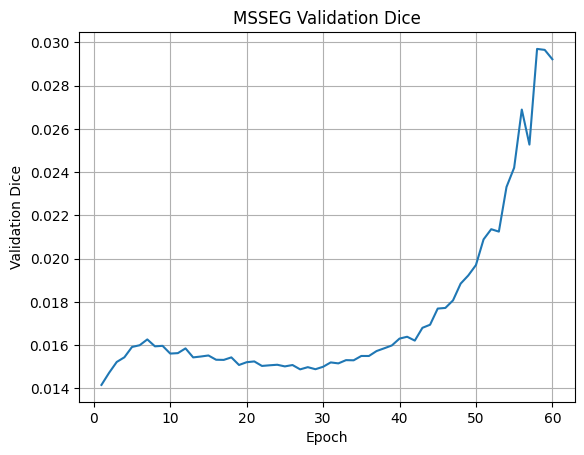

In [22]:
import os
import matplotlib.pyplot as plt
import pandas as pd

ms_hist_csv = "/content/work_msseg/outputs/msseg_training_history.csv"
ms_hist_df = pd.read_csv(ms_hist_csv)

plt.figure()
plt.plot(ms_hist_df["epoch"], ms_hist_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MSSEG Train Loss")
plt.grid(True)
plt.savefig("/content/work_msseg/outputs/msseg_train_loss.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(ms_hist_df["epoch"], ms_hist_df["val_dice"])
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("MSSEG Validation Dice")
plt.grid(True)
plt.savefig("/content/work_msseg/outputs/msseg_val_dice.png", dpi=200, bbox_inches="tight")
plt.show()

Loaded best epoch: 58
Loaded best val Dice: 0.029701635241508484


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


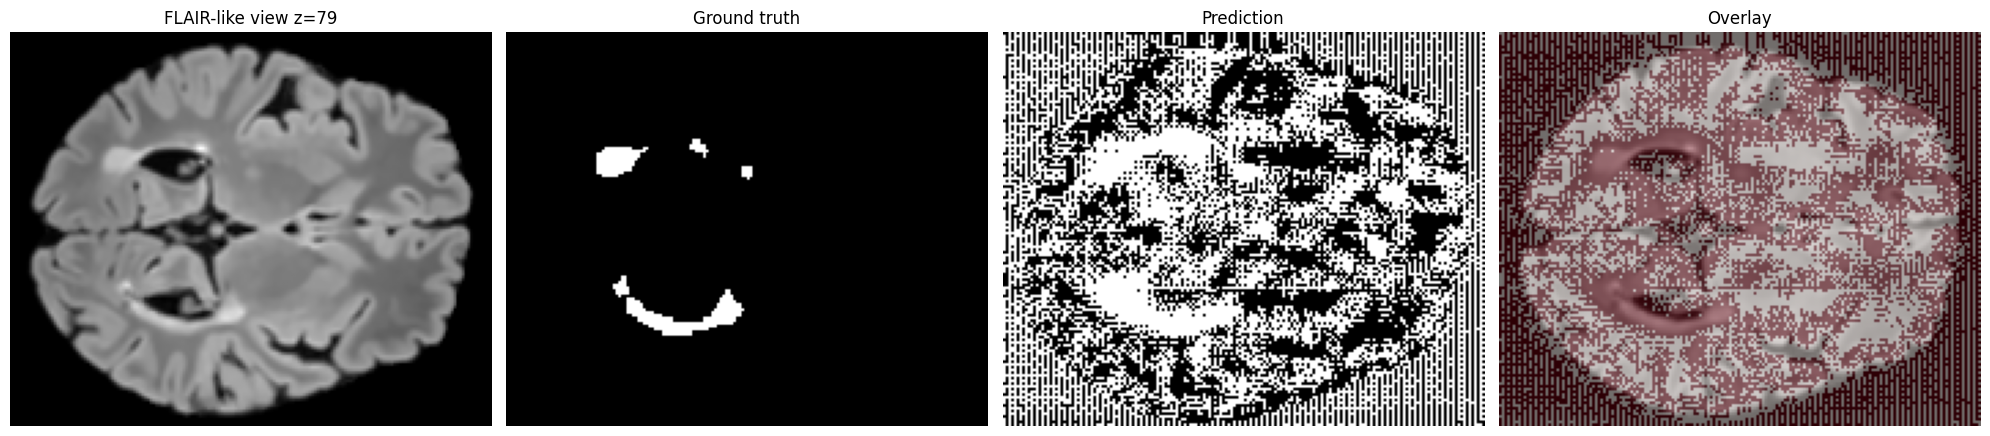

Saved: /content/work_msseg/outputs/msseg_prediction_example.png


In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference

best_path = "/content/work_msseg/outputs/best_msseg_unet.pt"
ckpt = torch.load(best_path, map_location=device)
ms_model.load_state_dict(ckpt["model_state_dict"])
ms_model.eval()

print("Loaded best epoch:", ckpt["epoch"])
print("Loaded best val Dice:", ckpt["val_dice"])

batch = next(iter(ms_val_loader))
image = batch["image"].to(device)
label = batch["label"].to(device)

with torch.no_grad():
    pred = sliding_window_inference(
        inputs=image,
        roi_size=(96, 96, 96),
        sw_batch_size=1,
        predictor=ms_model,
        overlap=0.25,
    )
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    # ---- remove tiny lesions ----
    from skimage.morphology import remove_small_objects

    pred_np = pred.cpu().numpy()

    clean_pred = np.zeros_like(pred_np)

    for i in range(pred_np.shape[0]):
        clean_pred[i,0] = remove_small_objects(
            pred_np[i,0].astype(bool),
            min_size=50
        )

    pred = torch.from_numpy(clean_pred).float().to(device)

img_np = image.cpu().numpy()[0, 0]   # first modality view for display
lab_np = label.cpu().numpy()[0, 0]
pred_np = pred.cpu().numpy()[0, 0]

z_idx = int(np.argmax([lab_np[:, :, z].sum() for z in range(lab_np.shape[2])]))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_np[:, :, z_idx], cmap="gray")
axes[0].set_title(f"FLAIR-like view z={z_idx}")
axes[0].axis("off")

axes[1].imshow(lab_np[:, :, z_idx], cmap="gray")
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(pred_np[:, :, z_idx], cmap="gray")
axes[2].set_title("Prediction")
axes[2].axis("off")

axes[3].imshow(img_np[:, :, z_idx], cmap="gray")
axes[3].imshow(pred_np[:, :, z_idx], cmap="Reds", alpha=0.45)
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("/content/work_msseg/outputs/msseg_prediction_example.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: /content/work_msseg/outputs/msseg_prediction_example.png")

In [24]:
import json
import os

ms_summary = {
    "task": "MS lesion segmentation",
    "dataset": "MSSEG 2016 Training",
    "model": "MONAI 3D UNet",
    "input_channels": 4,
    "modalities": ["FLAIR", "T1", "T2", "DP"],
    "label": "Consensus lesion mask",
    "epochs": 60,
    "best_val_dice": float(ckpt["val_dice"]),
    "best_epoch": int(ckpt["epoch"]),
    "train_cases": len(train_files),
    "val_cases": len(val_files),
    "output_dir": "/content/work_msseg/outputs"
}

summary_path = "/content/work_msseg/outputs/msseg_summary.json"
with open(summary_path, "w") as f:
    json.dump(ms_summary, f, indent=2)

print("Saved:", summary_path)
print(ms_summary)

Saved: /content/work_msseg/outputs/msseg_summary.json
{'task': 'MS lesion segmentation', 'dataset': 'MSSEG 2016 Training', 'model': 'MONAI 3D UNet', 'input_channels': 4, 'modalities': ['FLAIR', 'T1', 'T2', 'DP'], 'label': 'Consensus lesion mask', 'epochs': 60, 'best_val_dice': 0.029701635241508484, 'best_epoch': 58, 'train_cases': 12, 'val_cases': 3, 'output_dir': '/content/work_msseg/outputs'}


In [25]:
# ===== MSSEG 3-fold cross-validation: split =====

from sklearn.model_selection import KFold
import numpy as np

num_folds = 3
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

fold_splits = []
for fold_id, (train_idx, val_idx) in enumerate(kf.split(data_dicts), start=1):
    train_fold = [data_dicts[i] for i in train_idx]
    val_fold = [data_dicts[i] for i in val_idx]

    print(f"Fold {fold_id}: train={len(train_fold)}, val={len(val_fold)}")
    fold_splits.append((train_fold, val_fold))

Fold 1: train=10, val=5
Fold 2: train=10, val=5
Fold 3: train=10, val=5


In [26]:
# ===== reusable fold training function =====

import os
import torch
import pandas as pd
from monai.networks.nets import UNet
from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete, Compose
from monai.data import Dataset, DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from tqdm import tqdm

def run_msseg_fold(fold_id, train_files, val_files, epochs=30):
    print(f"\n========== FOLD {fold_id} ==========")

    # datasets
    train_ds = Dataset(data=train_files, transform=ms_train_transforms)
    val_ds = Dataset(data=val_files, transform=ms_val_transforms)

    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

    # fresh model each fold
    model = UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    ).to(device)

    loss_fn = DiceFocalLoss(sigmoid=True, lambda_dice=0.7, lambda_focal=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    dice_metric = DiceMetric(include_background=True, reduction="mean")
    post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
    post_label = Compose([AsDiscrete(threshold=0.5)])

    def validate():
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for batch in val_loader:
                val_images = batch["image"].to(device)
                val_labels = batch["label"].to(device)

                val_outputs = sliding_window_inference(
                    inputs=val_images,
                    roi_size=(96, 96, 96),
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.25,
                )

                val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

                dice_metric(y_pred=val_outputs_list, y=val_labels_list)

        score = dice_metric.aggregate().item()
        dice_metric.reset()
        return score

    best_dice = -1
    best_epoch = -1
    history = []

    fold_out_dir = f"/content/work_msseg/outputs/fold_{fold_id}"
    os.makedirs(fold_out_dir, exist_ok=True)
    best_path = os.path.join(fold_out_dir, f"best_msseg_fold{fold_id}.pt")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        step = 0

        pbar = tqdm(train_loader, desc=f"[Fold {fold_id} | Epoch {epoch+1}/{epochs}]")

        for batch in pbar:
            step += 1
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        epoch_loss /= step
        val_dice = validate()

        history.append({
            "fold": fold_id,
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "val_dice": val_dice,
        })

        print(f"[Fold {fold_id} | Epoch {epoch+1}] train_loss={epoch_loss:.4f} val_dice={val_dice:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            best_epoch = epoch + 1
            torch.save({
                "fold": fold_id,
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "val_dice": best_dice,
            }, best_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(fold_out_dir, f"fold_{fold_id}_history.csv"), index=False)

    print(f"Fold {fold_id} best Dice: {best_dice:.4f} at epoch {best_epoch}")
    return {
        "fold": fold_id,
        "best_dice": best_dice,
        "best_epoch": best_epoch,
        "best_model_path": best_path,
        "history": hist_df,
    }

In [27]:
# ===== run 3-fold cross-validation =====

cv_results = []

for fold_id, (train_fold, val_fold) in enumerate(fold_splits, start=1):
    result = run_msseg_fold(
        fold_id=fold_id,
        train_files=train_fold,
        val_files=val_fold,
        epochs=30
    )
    cv_results.append(result)


========== FOLD 1 ==========


[Fold 1 | Epoch 1/30]: 100%|██████████| 10/10 [01:03<00:00,  6.31s/it, loss=0.785]


[Fold 1 | Epoch 1] train_loss=0.7987 val_dice=0.0099


[Fold 1 | Epoch 2/30]: 100%|██████████| 10/10 [01:03<00:00,  6.38s/it, loss=0.749]


[Fold 1 | Epoch 2] train_loss=0.7821 val_dice=0.0093


...

[Fold 3 | Epoch 28] train_loss=0.7302 val_dice=0.0257


[Fold 3 | Epoch 29/30]: 100%|██████████| 10/10 [01:06<00:00,  6.69s/it, loss=0.717]


[Fold 3 | Epoch 29] train_loss=0.7313 val_dice=0.0288


[Fold 3 | Epoch 30/30]: 100%|██████████| 10/10 [01:07<00:00,  6.76s/it, loss=0.681]


[Fold 3 | Epoch 30] train_loss=0.7302 val_dice=0.0285
Fold 3 best Dice: 0.0288 at epoch 29


In [28]:
# ===== summarize CV results =====

import numpy as np
import pandas as pd
import json

fold_dices = [r["best_dice"] for r in cv_results]
fold_epochs = [r["best_epoch"] for r in cv_results]

print("Fold best Dice:", fold_dices)
print("Fold best epochs:", fold_epochs)
print("Mean Dice:", float(np.mean(fold_dices)))
print("Std Dice:", float(np.std(fold_dices)))

cv_summary = {
    "task": "MS lesion segmentation",
    "dataset": "MSSEG 2016 Training",
    "model": "MONAI 3D UNet",
    "input_channels": 4,
    "modalities": ["FLAIR", "T1", "T2", "DP"],
    "num_folds": 3,
    "epochs_per_fold": 30,
    "fold_best_dice": [float(x) for x in fold_dices],
    "fold_best_epoch": [int(x) for x in fold_epochs],
    "mean_dice": float(np.mean(fold_dices)),
    "std_dice": float(np.std(fold_dices)),
}

cv_summary_path = "/content/work_msseg/outputs/msseg_cv_summary.json"
with open(cv_summary_path, "w") as f:
    json.dump(cv_summary, f, indent=2)

print("Saved:", cv_summary_path)

pd.DataFrame({
    "fold": list(range(1, len(fold_dices)+1)),
    "best_dice": fold_dices,
    "best_epoch": fold_epochs
}).to_csv("/content/work_msseg/outputs/msseg_cv_results.csv", index=False)

print("Saved: /content/work_msseg/outputs/msseg_cv_results.csv")

Fold best Dice: [0.010494857095181942, 0.060520239174366, 0.028799140825867653]
Fold best epochs: [30, 29, 29]
Mean Dice: 0.03327141236513853
Std Dice: 0.020666165949571078
Saved: /content/work_msseg/outputs/msseg_cv_summary.json
Saved: /content/work_msseg/outputs/msseg_cv_results.csv


In [29]:
import os
from google.colab import files

output_dir = "/content/work_msseg/outputs"
print("Files in outputs:")
for f in sorted(os.listdir(output_dir)):
    print(f)

Files in outputs:
best_msseg_unet.pt
fold_1
fold_2
fold_3
msseg_cv_results.csv
msseg_cv_summary.json
msseg_prediction_example.png
msseg_summary.json
msseg_train_loss.png
msseg_training_history.csv
msseg_val_dice.png


In [30]:
from google.colab import files

to_download = [
    "/content/work_msseg/outputs/best_msseg_unet.pt",
    "/content/work_msseg/outputs/msseg_training_history.csv",
    "/content/work_msseg/outputs/msseg_cv_results.csv",
    "/content/work_msseg/outputs/msseg_cv_summary.json",
    "/content/work_msseg/outputs/msseg_prediction_example.png",
    "/content/work_msseg/outputs/msseg_val_dice.png",
]

for f in to_download:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
baseline_summary = """
MSSEG baseline completed successfully.

Model:
- MONAI 3D UNet
- Input channels: 4 (FLAIR, T1, T2, DP)

Single split:
- Training completed for 60 epochs
- Best validation Dice: 0.0297 at epoch 58

3-fold CV:
- Fold 1 best Dice: 0.0105
- Fold 2 best Dice: 0.0605
- Fold 3 best Dice: 0.0288
- Mean Dice: 0.0333
- Std Dice: 0.0207

Conclusion:
- Pipeline works end-to-end
- Current segmentation quality is weak and predictions remain noisy
- This serves as a baseline for improvement
"""
print(baseline_summary)


MSSEG baseline completed successfully.

Model:
- MONAI 3D UNet
- Input channels: 4 (FLAIR, T1, T2, DP)

Single split:
- Training completed for 60 epochs
- Best validation Dice: 0.0297 at epoch 58

3-fold CV:
- Fold 1 best Dice: 0.0105
- Fold 2 best Dice: 0.0605
- Fold 3 best Dice: 0.0288
- Mean Dice: 0.0333
- Std Dice: 0.0207

Conclusion:
- Pipeline works end-to-end
- Current segmentation quality is weak and predictions remain noisy
- This serves as a baseline for improvement

